In [160]:
import os

import pandas as pd
import polars as pl
import itertools
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report

In [147]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning to Rank'

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
sp_df = pl.read_csv('StudentsPerformance.csv')

In [4]:
sp_df

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
str,str,str,str,str,i64,i64,i64
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75
…,…,…,…,…,…,…,…
"""female""","""group E""","""master's degree""","""standard""","""completed""",88,99,95
"""male""","""group C""","""high school""","""free/reduced""","""none""",62,55,55
"""female""","""group C""","""high school""","""free/reduced""","""completed""",59,71,65


In [5]:
sp_df = sp_df.with_columns(
    (pl.col("math score") + pl.col("reading score") + pl.col("writing score")).alias("total")    
)

In [6]:
sp_df

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total
str,str,str,str,str,i64,i64,i64,i64
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74,218
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88,247
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93,278
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44,148
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75,229
…,…,…,…,…,…,…,…,…
"""female""","""group E""","""master's degree""","""standard""","""completed""",88,99,95,282
"""male""","""group C""","""high school""","""free/reduced""","""none""",62,55,55,172
"""female""","""group C""","""high school""","""free/reduced""","""completed""",59,71,65,195


In [7]:
sp_df = sp_df.with_columns(
    pl.format("ID_{}", pl.arange(0, pl.len())).alias("ID")    
)

In [8]:
sp_df

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total,ID
str,str,str,str,str,i64,i64,i64,i64,str
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74,218,"""ID_0"""
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88,247,"""ID_1"""
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93,278,"""ID_2"""
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44,148,"""ID_3"""
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75,229,"""ID_4"""
…,…,…,…,…,…,…,…,…,…
"""female""","""group E""","""master's degree""","""standard""","""completed""",88,99,95,282,"""ID_995"""
"""male""","""group C""","""high school""","""free/reduced""","""none""",62,55,55,172,"""ID_996"""
"""female""","""group C""","""high school""","""free/reduced""","""completed""",59,71,65,195,"""ID_997"""


In [9]:
sp_df = sp_df.with_columns(
    pl.concat_list(["math score", "reading score","writing score"]).alias("features")
)

In [10]:
sp_df

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total,ID,features
str,str,str,str,str,i64,i64,i64,i64,str,list[i64]
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74,218,"""ID_0""","[72, 72, 74]"
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88,247,"""ID_1""","[69, 90, 88]"
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93,278,"""ID_2""","[90, 95, 93]"
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44,148,"""ID_3""","[47, 57, 44]"
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75,229,"""ID_4""","[76, 78, 75]"
…,…,…,…,…,…,…,…,…,…,…
"""female""","""group E""","""master's degree""","""standard""","""completed""",88,99,95,282,"""ID_995""","[88, 99, 95]"
"""male""","""group C""","""high school""","""free/reduced""","""none""",62,55,55,172,"""ID_996""","[62, 55, 55]"
"""female""","""group C""","""high school""","""free/reduced""","""completed""",59,71,65,195,"""ID_997""","[59, 71, 65]"


In [11]:
sp_df = sp_df.select(["ID", "features", "total"])
sp_df

ID,features,total
str,list[i64],i64
"""ID_0""","[72, 72, 74]",218
"""ID_1""","[69, 90, 88]",247
"""ID_2""","[90, 95, 93]",278
"""ID_3""","[47, 57, 44]",148
"""ID_4""","[76, 78, 75]",229
…,…,…
"""ID_995""","[88, 99, 95]",282
"""ID_996""","[62, 55, 55]",172
"""ID_997""","[59, 71, 65]",195


In [90]:
sample_df = sp_df[:100]
sample_df

ID,features,total
str,list[i64],i64
"""ID_0""","[72, 72, 74]",218
"""ID_1""","[69, 90, 88]",247
"""ID_2""","[90, 95, 93]",278
"""ID_3""","[47, 57, 44]",148
"""ID_4""","[76, 78, 75]",229
…,…,…
"""ID_95""","[78, 81, 82]",241
"""ID_96""","[65, 66, 62]",193
"""ID_97""","[63, 72, 70]",205


In [91]:
# Doing the permutation using cross join
permuted_df = sample_df.join(sample_df, how="cross")

In [92]:
permuted_df

ID,features,total,ID_right,features_right,total_right
str,list[i64],i64,str,list[i64],i64
"""ID_0""","[72, 72, 74]",218,"""ID_0""","[72, 72, 74]",218
"""ID_0""","[72, 72, 74]",218,"""ID_1""","[69, 90, 88]",247
"""ID_0""","[72, 72, 74]",218,"""ID_2""","[90, 95, 93]",278
"""ID_0""","[72, 72, 74]",218,"""ID_3""","[47, 57, 44]",148
"""ID_0""","[72, 72, 74]",218,"""ID_4""","[76, 78, 75]",229
…,…,…,…,…,…
"""ID_99""","[65, 67, 62]",194,"""ID_95""","[78, 81, 82]",241
"""ID_99""","[65, 67, 62]",194,"""ID_96""","[65, 66, 62]",193
"""ID_99""","[65, 67, 62]",194,"""ID_97""","[63, 72, 70]",205


In [93]:
permuted_df = permuted_df.with_columns(
    pl.when(pl.col("total") > pl.col("total_right")).then(2)
      .when(pl.col("total") < pl.col("total_right")).then(0)
      .otherwise(1)
      .alias("label")
)

In [94]:
permuted_df

ID,features,total,ID_right,features_right,total_right,label
str,list[i64],i64,str,list[i64],i64,i32
"""ID_0""","[72, 72, 74]",218,"""ID_0""","[72, 72, 74]",218,1
"""ID_0""","[72, 72, 74]",218,"""ID_1""","[69, 90, 88]",247,0
"""ID_0""","[72, 72, 74]",218,"""ID_2""","[90, 95, 93]",278,0
"""ID_0""","[72, 72, 74]",218,"""ID_3""","[47, 57, 44]",148,2
"""ID_0""","[72, 72, 74]",218,"""ID_4""","[76, 78, 75]",229,0
…,…,…,…,…,…,…
"""ID_99""","[65, 67, 62]",194,"""ID_95""","[78, 81, 82]",241,0
"""ID_99""","[65, 67, 62]",194,"""ID_96""","[65, 66, 62]",193,2
"""ID_99""","[65, 67, 62]",194,"""ID_97""","[63, 72, 70]",205,0


In [95]:
permuted_df.group_by("label").len()

label,len
i32,u32
1,172
2,4914
0,4914


In [96]:
# Combine features column into single column
permuted_df = permuted_df.with_columns(
    pl.concat_list("features", "features_right").alias("combined_features")
)

permuted_df

ID,features,total,ID_right,features_right,total_right,label,combined_features
str,list[i64],i64,str,list[i64],i64,i32,list[i64]
"""ID_0""","[72, 72, 74]",218,"""ID_0""","[72, 72, 74]",218,1,"[72, 72, … 74]"
"""ID_0""","[72, 72, 74]",218,"""ID_1""","[69, 90, 88]",247,0,"[72, 72, … 88]"
"""ID_0""","[72, 72, 74]",218,"""ID_2""","[90, 95, 93]",278,0,"[72, 72, … 93]"
"""ID_0""","[72, 72, 74]",218,"""ID_3""","[47, 57, 44]",148,2,"[72, 72, … 44]"
"""ID_0""","[72, 72, 74]",218,"""ID_4""","[76, 78, 75]",229,0,"[72, 72, … 75]"
…,…,…,…,…,…,…,…
"""ID_99""","[65, 67, 62]",194,"""ID_95""","[78, 81, 82]",241,0,"[65, 67, … 82]"
"""ID_99""","[65, 67, 62]",194,"""ID_96""","[65, 66, 62]",193,2,"[65, 67, … 62]"
"""ID_99""","[65, 67, 62]",194,"""ID_97""","[63, 72, 70]",205,0,"[65, 67, … 70]"


In [97]:
# Select X and y
X = permuted_df.select(pl.col('combined_features')).to_series().to_list()
y = permuted_df.select(pl.col('label')).to_series().to_list()

In [98]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

In [99]:
class Classifier(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=3):
        super(Classifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Linear(hidden2_size, output_size)
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return torch.argmax(outputs, dim=1)

In [100]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    
    return device

In [101]:
get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


device(type='cuda')

In [102]:
def prepare_data(X, y):
    # Split the dataset into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [103]:
def create_data_loaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32, device=None):

    if device is None:
        device = get_device()
    
    X_train = torch.from_numpy(X_train).float().to(device)
    X_val = torch.from_numpy(X_val).float().to(device)
    X_test = torch.from_numpy(X_test).float().to(device)
    
    y_train = torch.from_numpy(y_train).long().to(device)
    y_val = torch.from_numpy(y_val).long().to(device)
    y_test = torch.from_numpy(y_test).long().to(device)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [149]:
def train_model(model, train_loader, val_loader, optimizer_type='adam', learning_rate=0.01, num_epochs=100):

    # Output setup
    best_val_metric = float('-inf')
    best_model_path = 'ranking.pth'

    # For tracking train and validation
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_aucs, val_aucs = [], []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    model.to(device)
    
    # Choose optimizer
    if optimizer_type.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Optimizer must be 'sgd' or 'adam'")

     # Loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_true_labels = []
        train_predicted_probs = []

        for inputs, labels in train_loader:
            
            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
    
            train_true_labels.extend(labels.cpu().numpy())
            train_predicted_probs.extend(predicted.cpu().numpy())

        
        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        train_losses.append(round(avg_train_loss, 4))
        train_accuracies.append(round(train_accuracy, 2))

        # Validation phase
        model.eval()
        total_val_loss = 0
        correct_predictions = 0
        total_predictions = 0
        val_metric = 0
        val_true_labels = []
        val_predicted_probs = []
    
        with torch.no_grad():
            for inputs, labels in val_loader:
                # Forward pass
                outputs = model(inputs)
    
                # Compute validation loss
                val_loss = criterion(outputs, labels)
                total_val_loss += val_loss.item()
    
                # Compute accuracy
                _, predicted = torch.max(outputs, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

                val_true_labels.extend(labels.cpu().numpy())
                val_predicted_probs.extend(predicted.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = 100 * correct_predictions / total_predictions
        val_metric = correct_predictions / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_probs, 
            average='macro',  # Use macro average for multi-class classification
            zero_division=1.0
        )

        # Save the best model
        if val_metric > best_val_metric:
            best_val_metric = val_metric
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with validation metric: {best_val_metric:.4f}")
        
        val_true_labels = np.array(val_true_labels)
        val_predicted_probs = np.array(val_predicted_probs)
    
        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))
    
        # Print progress
        print(f'Epoch [{epoch+1}/{num_epochs}] - '
              f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}% - '
              f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
              f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
        )

        metrics = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies, 
            'val_accuracies': val_accuracies,
            'val_precisions': val_precisions,
            'val_recalls': val_recalls,
            'val_f1_scores': val_f1_scores
        }
    
    return model, metrics

In [150]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X, y)

In [151]:
train_loader, val_loader, test_loader = create_data_loaders(X_train, X_val, X_test, y_train, y_val, y_test)

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [152]:
model = Classifier(input_size=X_train.shape[1])

In [153]:
X_train.shape

(3340, 6)

In [155]:
trained_model, metrics = train_model(model, train_loader, val_loader)

New best model saved with validation metric: 31.1905
Epoch [1/100] - [TRAIN] Loss: 0.0652, Accuracy: 97.43% - [VAL] Loss: 0.0367, Accuracy: 98.35%, Precision: 0.99, Recall: 0.70, F1-Score: 0.71, 
Epoch [2/100] - [TRAIN] Loss: 0.0587, Accuracy: 97.60% - [VAL] Loss: 0.0706, Accuracy: 96.31%, Precision: 0.65, Recall: 0.65, F1-Score: 0.65, 
Epoch [3/100] - [TRAIN] Loss: 0.0591, Accuracy: 97.49% - [VAL] Loss: 0.1044, Accuracy: 96.31%, Precision: 0.65, Recall: 0.65, F1-Score: 0.65, 
Epoch [4/100] - [TRAIN] Loss: 0.0813, Accuracy: 97.07% - [VAL] Loss: 0.1311, Accuracy: 95.74%, Precision: 0.64, Recall: 0.65, F1-Score: 0.64, 
Epoch [5/100] - [TRAIN] Loss: 0.0950, Accuracy: 96.32% - [VAL] Loss: 0.0496, Accuracy: 97.66%, Precision: 0.98, Recall: 0.66, F1-Score: 0.66, 
Epoch [6/100] - [TRAIN] Loss: 0.0609, Accuracy: 97.37% - [VAL] Loss: 0.0450, Accuracy: 97.81%, Precision: 0.99, Recall: 0.66, F1-Score: 0.66, 
Epoch [7/100] - [TRAIN] Loss: 0.0592, Accuracy: 97.60% - [VAL] Loss: 0.0340, Accuracy: 98

In [162]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy, kernel_size')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = 'training_vs_validation_ranking.png'
    plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'train', img_name))
    
    plt.show()

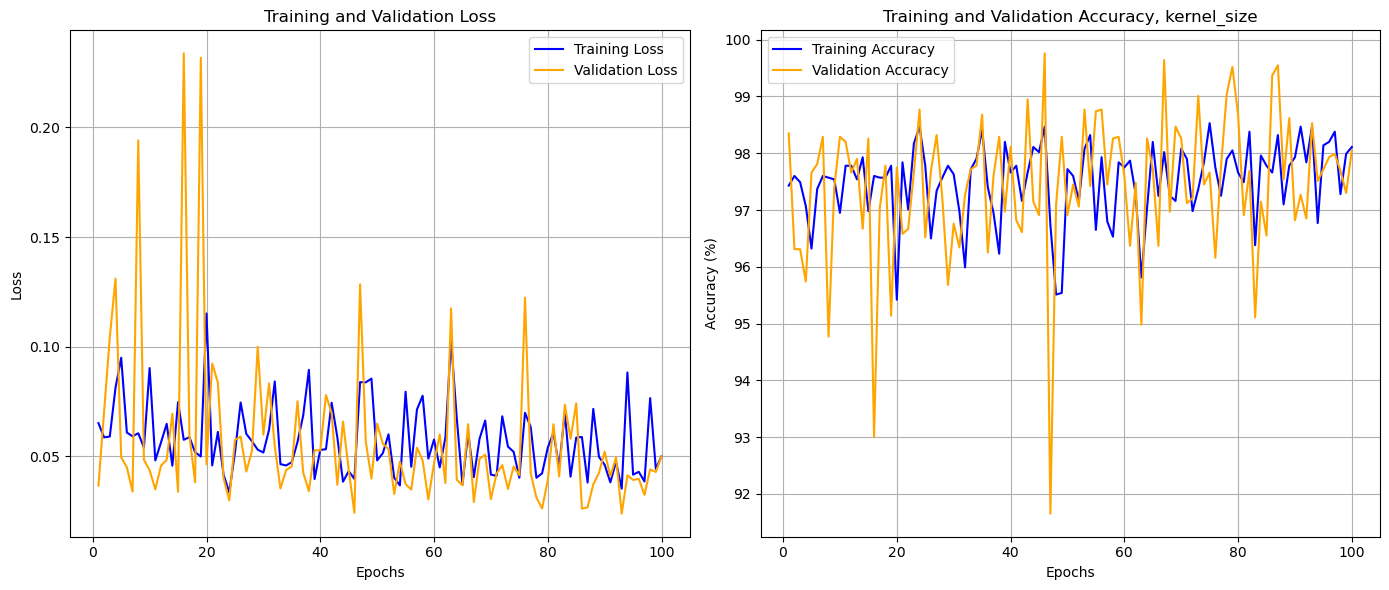

In [163]:
plot_metrics(metrics['train_losses'], metrics['val_losses'], metrics['train_accuracies'], metrics['val_accuracies'])

In [164]:
trained_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = trained_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

In [165]:
# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='macro'  # Use 'macro' for multi-class
)
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")

# test_auc_score = roc_auc_score(test_true_labels, test_predictions, multi_class='ovo')

# print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Accuracy Score on test set: 97.99 %
Precision: 0.8199
Recall: 0.9864
F1-Score: 0.8697


In [166]:
# Load the best model
best_model = Classifier(input_size=X_train.shape[1]).to(device)
best_model.load_state_dict(torch.load('ranking.pth'))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        # probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='macro',  # Use 'macro' for multi-class
    zero_division=1.0
)
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
# test_auc_score = roc_auc_score(test_true_labels, test_predictions)
# print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 99.67 %
Precision: 0.9739
Recall: 0.9582
F1-Score: 0.9658

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1637
           1       0.93      0.88      0.90        57
           2       1.00      1.00      1.00      1636

    accuracy                           1.00      3330
   macro avg       0.97      0.96      0.97      3330
weighted avg       1.00      1.00      1.00      3330


Confusion Matrix:
[[1633    4    0]
 [   0   50    7]
 [   0    0 1636]]
